# [웹 스크래핑 종합 과제] 에펨코리아 '포텐 터짐(화제)' 게시판 분석

## 0. 주제

**대상 사이트**: 에펨코리아(fmkorea) — 국내 대형 커뮤니티
**대상 게시판**: 포텐 터짐 - 화제순 (`https://www.fmkorea.com/best2`)

fmkorea의 `best2`는 커뮤니티 전체 게시판을 통틀어 현재 화제가 되고 있는 글을 모아 보여주는
실시간 인기글 랭킹 피드입니다. 페이지 번호(`?page=N`)로 계속 넘기면서 과거 인기글을 볼 수 있습니다.

## 1. 분석 질문

> **화제글의 카테고리에 따라 추천수(화제성)와 댓글수(참여도)가 어떻게 달라질까?**
> 그리고 화제글은 요일에 따라 발생 빈도가 다를까?

필요한 컬럼: `카테고리`, `추천수`, `댓글수`, `작성일자`(요일 계산용)

## 2. 수집 대상 & 범위 결정

- URL: `https://www.fmkorea.com/best2?page=N`
- 수집 항목: 작성자, 카테고리, 제목, 작성일자, 추천수, 댓글수, 게시글 URL

**범위에 대한 중요한 사전 조사 결과** — 처음에는 "2026-01-01 ~ 2026-07-23" 처럼 특정 기간을
지정해서 모으려 했지만, 실제로 사이트를 확인해보니 `best2`는 캘린더 날짜로 조회하는 게시판이
아니라 그냥 페이지 번호로 넘기는 실시간 랭킹 피드였습니다. 브라우저로 직접 페이지를 넘겨 확인한
결과:

| 페이지 | 실제 날짜 |
| :--- | :--- |
| 1 | 2026.07.23 (오늘) |
| 100 | 2026.07.19 |
| 130 | 2026.07.18 ~ 07.19 |
| 140 이후 | 게시글 없음 (실제 데이터 끝) |

즉 `best2`는 최근 약 열흘 안팎의 데이터만 유지되고 그 이후 페이지는 비어 있습니다. 7개월치를
모으려면 수만 페이지를 요청해야 하는데, 이는 아래 "반드시 지켜야 할 점"에 있는 "요청 사이에
간격을 두고 서버에 부담 주지 않기" 원칙과 정면으로 충돌합니다. 그래서 **날짜를 지정해서 모으는
대신, 페이지를 최대 200페이지까지 넘기면서 실제로 게시글이 나오는 만큼만 모으고, 모은 뒤
`작성일자` 기준으로 정렬**하는 방식으로 범위를 조정했습니다. (아래 3장에서 실제로 몇 페이지에서
데이터가 끝나는지 코드로도 확인합니다.)

**목록 페이지에는 조회수가 없습니다.** 상세 페이지를 하나씩 더 방문해야 조회수를 얻을 수 있는데,
페이지당 20건 x 최대 200페이지 = 최대 4,000건에 대해 상세 페이지까지 방문하면 요청 수가 2배로
늘어나고 수집 시간이 과제 권장 시간(50분)을 크게 넘기게 됩니다. 이번 분석 질문(카테고리 vs
추천수·댓글수)에는 조회수가 필수가 아니므로, **조회수 수집은 범위에서 제외**했습니다.

## 윤리·법 체크

- `robots.txt` 확인: 이름이 지정된 AI 크롤러(`anthropic-ai`, `ClaudeBot` 등)는 차단되어 있지만,
  이름이 없는 일반 봇(`User-agent: *`)에게는 `/best2`가 명시적으로 허용되어 있습니다.
- 로그인이 필요 없는 공개 게시판만 수집하며, 실명·연락처 등 개인정보는 수집하지 않습니다
  (수집하는 '작성자'는 사이트에 공개된 닉네임입니다).
- 요청 사이에 `time.sleep()`으로 딜레이를 둡니다.
- 수집 목적은 학습용이며, 재배포·상업적 이용을 하지 않습니다.

## 3. 데이터 수집

### 3-0. 환경 준비 (Playwright)

fmkorea가 최근 **DDoS 방어 시스템(WASM 챌린지)**을 추가해서, `requests`처럼 JS를 실행하지 않는
방식으로 요청을 보내면 실제 게시글이 아니라 HTTP 430 차단 페이지만 돌아옵니다. 이 챌린지는
브라우저에서 JS/WASM을 실행해 검증 쿠키를 만든 뒤 자동 새로고침이 되어야 통과되는 구조라, JS를
실행하지 않는 라이브러리로는 우회할 수 없습니다 (그리고 이 챌린지 로직을 역산해서 우회하는 것도
하지 않습니다). 대신 **Playwright**로 실제 headless 브라우저를 띄워서, 사이트가 의도한 대로
JS/WASM이 정상적으로 실행되게 하고, 그 결과 렌더링된 HTML을 그대로 `BeautifulSoup`으로 파싱합니다.

최초 1회만 아래 셀의 주석을 풀어서 실행하면 됩니다.

In [1]:
# 최초 1회만 실행: Playwright 라이브러리 + Chromium 바이너리 설치
# !pip install playwright
# !playwright install chromium

In [2]:
import asyncio
import re
import time
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime, timedelta
from urllib.parse import urljoin

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from bs4 import BeautifulSoup
from playwright.sync_api import sync_playwright

# 그래프에 한글이 나오므로 처음부터 한글 폰트를 지정해 둡니다 (Windows 기본 탑재 폰트).
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료!')

라이브러리 로드 완료!


### 3-1. 설정값

- `MAX_PAGE_COUNT`: 수집할 목록 페이지 수의 **상한**(1페이지 = 20건). 실제로는 이보다 먼저
  데이터가 끝나면 자동으로 멈춥니다 (아래 `run_scraper` 참고).
- `MAX_CONSECUTIVE_EMPTY`: 이 횟수만큼 연속으로 빈 페이지가 나오면 "실제 데이터가 끝났다"고
  보고 수집을 중단합니다. 사전 조사에서 확인했듯 140페이지 이후로는 게시글이 없었습니다.
- `REQUEST_DELAY` / `RENDER_WAIT`: 서버 부담을 줄이기 위한 요청 간 대기 시간과, DDoS 챌린지가
  통과되고 실제 콘텐츠가 렌더링될 때까지 기다리는 시간입니다.

In [3]:
BASE_URL = 'https://www.fmkorea.com'
LIST_URL = f'{BASE_URL}/best2'

# 일반 브라우저로 보이는 User-Agent (이름이 지정된 AI 크롤러 UA는 robots.txt에서 차단되어 있음)
USER_AGENT = (
    'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
    '(KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36'
)

MAX_PAGE_COUNT = 200        # 수집할 목록 페이지 수 상한 (1페이지 = 20건)
MAX_CONSECUTIVE_EMPTY = 2   # 연속으로 이 횟수만큼 빈 페이지가 나오면 수집 중단
REQUEST_DELAY = 1.0         # 요청 사이 대기 시간(초)
RENDER_WAIT = 3.5           # DDoS 챌린지 통과 + 렌더링 대기 시간(초)

### 3-2. Playwright로 렌더링된 HTML 가져오기

`page.goto()`로 이동한 뒤 `RENDER_WAIT`만큼 기다려서 DDoS 챌린지 스크립트가 쿠키를 세팅하고
자동 새로고침을 마칠 시간을 줍니다. `wait_until='load'`는 이미지·광고 등 모든 하위 리소스를
기다리다 타임아웃 나는 경우가 있어서, HTML 파싱이 끝나는 시점(`domcontentloaded`)까지만
기다립니다.

> **Windows + Jupyter 참고사항**: Jupyter 커널은 pyzmq와의 호환을 위해 asyncio 이벤트 루프
> 정책을 `Selector` 방식으로 바꿔두는데, Playwright(sync API)는 브라우저를 서브프로세스로
> 띄우고 `Selector` 루프는 Windows에서 서브프로세스를 지원하지 않아 오류가 납니다. 그래서 실제
> 크롤링은 별도 스레드(`ThreadPoolExecutor`)에서, 그 스레드 안에서만 `Proactor` 정책으로
> 바꿔서 실행합니다 (아래 `run_scraper` 참고).

In [4]:
# Playwright 페이지로 url을 방문해서 DDoS 챌린지 통과 후 최종 HTML을 반환합니다.
def fetch_rendered_html(page, url: str, params: dict | None = None) -> str:
    if params:
        query = '&'.join(f'{k}={v}' for k, v in params.items())
        url = f'{url}?{query}'

    page.goto(url, wait_until='domcontentloaded', timeout=30000)
    page.wait_for_timeout(int(RENDER_WAIT * 1000))
    return page.content()

### 3-3. 목록 페이지 파싱 함수

`div.fm_best_widget` 안의 `li.li` 항목마다 아래 정보를 뽑습니다.

| 항목 | CSS 선택자 |
| :--- | :--- |
| 제목 | `h3.title`의 `data-original-title` 속성 (말줄임 없는 전체 제목) |
| 카테고리 | `span.category a` (여러 개면 `-`로 연결) |
| 작성자 | `span.author` |
| 추천수 | `a.pc_voted_count .count` |
| 댓글수 | `.comment_count` (`[123]` 형태) |
| 작성일자(원본 텍스트) | `span.regdate` — `"3 분 전"` / `"22 시간 전"` / `"2026.07.22"` 세 가지 형태가 섞여 있습니다. 실제 날짜로 바꾸는 작업은 4장(정제)에서 합니다. |

In [5]:
# best2 목록 페이지 HTML 1개를 파싱해서 게시글 기본 정보 리스트를 반환합니다.
def parse_list_page(html: str) -> list[dict]:
    soup = BeautifulSoup(html, 'html.parser')

    posts = []
    for li in soup.select('div.fm_best_widget ul > li.li'):
        title_tag = li.select_one('h3.title')
        link_tag = li.select_one('h3.title a')
        if title_tag is None or link_tag is None:
            continue

        url = urljoin(BASE_URL, link_tag['href'])

        ellipsis_tag = title_tag.select_one('.ellipsis-target')
        title = title_tag.get('data-original-title') or (
            ellipsis_tag.get_text(strip=True) if ellipsis_tag else title_tag.get_text(strip=True)
        )

        category_links = li.select('span.category a')
        category = ' - '.join(a.get_text(strip=True) for a in category_links)

        author_tag = li.select_one('span.author')
        author = author_tag.get_text(strip=True).lstrip('/ ').strip() if author_tag else None

        recommend_tag = li.select_one('a.pc_voted_count .count')
        recommend_count = recommend_tag.get_text(strip=True) if recommend_tag else '0'

        comment_tag = li.select_one('.comment_count')
        comment_count = comment_tag.get_text(strip=True).strip('[]') if comment_tag else '0'

        regdate_tag = li.select_one('span.regdate')
        regdate_raw = regdate_tag.get_text(strip=True) if regdate_tag else None

        posts.append({
            'url': url,
            'title': title,
            'category': category,
            'author': author,
            'recommend_count': recommend_count,
            'comment_count': comment_count,
            'regdate_raw': regdate_raw,
        })

    return posts

### 3-4. 전체 수집 실행

목록 페이지를 1페이지부터 `MAX_PAGE_COUNT`까지 순서대로 방문합니다. 연속으로
`MAX_CONSECUTIVE_EMPTY`번 빈 페이지가 나오면 "실제 데이터가 끝났다"고 보고 그 자리에서 멈춥니다
(사전 조사에서 확인한 대로, 대략 130번대 페이지 이후로는 게시글이 없습니다). 그래서 실제로는
200페이지를 다 채우기 전에 훨씬 빨리 끝납니다.

In [6]:
def run_scraper() -> list[dict]:
    # 이 스레드에서만 Proactor 정책으로 전환 (Playwright의 서브프로세스 구동에 필요)
    if hasattr(asyncio, 'WindowsProactorEventLoopPolicy'):
        asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

    posts = []
    consecutive_empty = 0

    with sync_playwright() as p:
        browser = p.chromium.launch(headless=True)
        page = browser.new_page(user_agent=USER_AGENT)

        for page_num in range(1, MAX_PAGE_COUNT + 1):
            html = fetch_rendered_html(page, LIST_URL, params={'page': page_num})
            page_posts = parse_list_page(html)

            if not page_posts:
                consecutive_empty += 1
                print(f'{page_num} 페이지: 게시글 없음 ({consecutive_empty}번째 연속 빈 페이지)')
                if consecutive_empty >= MAX_CONSECUTIVE_EMPTY:
                    print(f'-> 연속 {MAX_CONSECUTIVE_EMPTY}회 빈 페이지: 실제 데이터가 끝난 것으로 보고 수집을 중단합니다.')
                    break
            else:
                consecutive_empty = 0
                posts.extend(page_posts)
                print(f'{page_num} 페이지: {len(page_posts)}건 수집 (누적 {len(posts)}건)')

            time.sleep(REQUEST_DELAY)

        browser.close()

    return posts


scraped_at = datetime.now()
with ThreadPoolExecutor(max_workers=1) as executor:
    all_posts = executor.submit(run_scraper).result()

print(f'수집 완료: 총 {len(all_posts)}건 (수집 시작 시각 {scraped_at:%Y-%m-%d %H:%M})')

1 페이지: 20건 수집 (누적 20건)


2 페이지: 20건 수집 (누적 40건)


3 페이지: 20건 수집 (누적 60건)


4 페이지: 20건 수집 (누적 80건)


5 페이지: 20건 수집 (누적 100건)


...

137 페이지: 13건 수집 (누적 2658건)


138 페이지: 13건 수집 (누적 2671건)


139 페이지: 게시글 없음 (1번째 연속 빈 페이지)


140 페이지: 게시글 없음 (2번째 연속 빈 페이지)
-> 연속 2회 빈 페이지: 실제 데이터가 끝난 것으로 보고 수집을 중단합니다.


수집 완료: 총 2671건 (수집 시작 시각 2026-07-24 00:32)


### 3-5. 원본 데이터 저장

정제 전 원본을 그대로 CSV로 남겨서, 정제 과정에서 무엇이 어떻게 바뀌었는지 나중에도 비교할 수
있게 합니다.

In [7]:
df_raw = pd.DataFrame(all_posts)
print('수집 시점:', scraped_at)
print('shape:', df_raw.shape)
df_raw.to_csv('fmkorea_best2_raw.csv', index=False, encoding='utf-8-sig')
df_raw.head()

수집 시점: 2026-07-24 00:32:42.454074
shape: (2671, 7)


,url,title,category,author,recommend_count,comment_count,regdate_raw
0,https://www.fmkorea.com/best2/10121064223,엄마 전재산 빼앗고 집에서 쫓아낸 막내딸!,유머 - 이슈,ㄱㅓ제야호,2087,783,4 시간 전
1,https://www.fmkorea.com/best2/10120960831,불침번 없앤다,유머,빵빵컴퓨터,2030,2960,5 시간 전
2,https://www.fmkorea.com/best2/10120755129,맥도날드 '지역 상생' 버거는 정말 농가에 도움이 될까?.jpg,유머,dk1022,2067,731,6 시간 전
3,https://www.fmkorea.com/best2/10121093748,동네에서 미친년이라고 소문남,유머,천량,1494,328,4 시간 전
4,https://www.fmkorea.com/best2/10120465954,이센스 인스타 입장문 발표,유머 - 이슈,바모스이강인,1836,853,8 시간 전


## 4. 데이터 정제

### 4-1. 결측치 확인

In [8]:
print('컬럼별 결측치 수:')
print(df_raw.isna().sum())
print()
print("카테고리가 빈 문자열인 게시글 수:", (df_raw['category'] == '').sum())
print("작성자가 없는 게시글 수:", df_raw['author'].isna().sum())

컬럼별 결측치 수:
url                0
title              0
category           0
author             0
recommend_count    0
comment_count      0
regdate_raw        0
dtype: int64

카테고리가 빈 문자열인 게시글 수: 0
작성자가 없는 게시글 수: 0


### 4-2. 결측치 처리

- **카테고리가 빈 문자열인 경우** → `'미분류'`로 채웁니다. 카테고리 없이 등록되는 게시글도
  실제로 존재하는 데이터이므로 제거하지 않고, 분석에서 하나의 그룹으로 남겨 둡니다.
- **작성일자를 해석할 수 없는 경우**(아래 4-4에서 파싱 후 확인) → 요일 분석에 쓸 수 없으므로
  해당 행만 제거합니다. 제목·추천수 등 다른 정보는 멀쩌하지만, 이번 분석 질문 자체가 카테고리와
  날짜를 축으로 하기 때문에 날짜를 모르는 행은 남겨둬도 활용할 수 없습니다.

In [9]:
df = df_raw.copy()
df['category'] = df['category'].replace('', '미분류')
df.loc[df['category'].isna(), 'category'] = '미분류'
print("처리 후 카테고리 결측/빈값:", (df['category'].isna() | (df['category'] == '')).sum())

처리 후 카테고리 결측/빈값: 0


### 4-3. 타입 변환

`추천수`·`댓글수`는 문자열로 수집되었습니다 (예: `"1,234"`, 아주 인기 많은 글은 `"1.2만"` 형태로
표시되는 경우도 있어 함께 처리합니다). 숫자형으로 바꿔야 그래프와 통계 계산이 가능합니다.

In [10]:
# '1,234' / '1.2만' 같은 표기를 정수로 변환합니다. 읽을 수 없으면 0으로 처리합니다.
def to_int(text: str) -> int:
    text = (text or '').strip().replace(',', '')
    if not text:
        return 0
    match = re.match(r'^(\d+(?:\.\d+)?)\s*만$', text)
    if match:
        return int(float(match.group(1)) * 10000)
    digits = re.sub(r'[^\d]', '', text)
    return int(digits) if digits else 0


df['추천수'] = df['recommend_count'].apply(to_int)
df['댓글수'] = df['comment_count'].apply(to_int)
df[['recommend_count', '추천수', 'comment_count', '댓글수']].head()

,recommend_count,추천수,comment_count,댓글수
0,2087,2087,783,783
1,2030,2030,2960,2960
2,2067,2067,731,731
3,1494,1494,328,328
4,1836,1836,853,853


### 4-4. 작성일자 정규화 + 파생 컬럼

목록 페이지의 날짜 표기는 `"3 분 전"` / `"22 시간 전"`(최근 게시글) 과 `"2026.07.22"`(하루
이상 지난 게시글)가 섞여 있습니다. 상대 시간 표기는 수집 시작 시각(`scraped_at`)을 기준으로
역산해서 실제 시각으로 바꿉니다. (수집이 몇 분~몇십 분에 걸쳐 진행되므로 약간의 오차가 있을 수
있지만, 이 분석은 '일 단위/요일 단위' 관찰이 목적이라 이 정도 오차는 무시할 수 있는 수준입니다.)

In [11]:
# 목록 페이지의 regdate 텍스트를 datetime으로 변환합니다. 못 읽으면 None.
def parse_regdate(raw, scraped_at: datetime):
    if not raw:
        return None
    raw = raw.strip()

    m = re.match(r'^(\d+)\s*분\s*전$', raw)
    if m:
        return scraped_at - timedelta(minutes=int(m.group(1)))

    m = re.match(r'^(\d+)\s*시간\s*전$', raw)
    if m:
        return scraped_at - timedelta(hours=int(m.group(1)))

    m = re.match(r'^(\d{4})\.(\d{2})\.(\d{2})$', raw)
    if m:
        y, mo, d = map(int, m.groups())
        return datetime(y, mo, d)

    return None


df['작성일시'] = df['regdate_raw'].apply(lambda x: parse_regdate(x, scraped_at))

failed = df['작성일시'].isna().sum()
print(f'작성일자를 해석할 수 없는 행: {failed}건 (제거합니다)')
df = df.dropna(subset=['작성일시']).copy()

WEEKDAY_KR = ['월', '화', '수', '목', '금', '토', '일']
df['작성일'] = df['작성일시'].dt.date
df['요일'] = df['작성일시'].dt.weekday.map(lambda i: WEEKDAY_KR[i])
df['대분류'] = df['category'].apply(lambda c: c.split(' - ')[0])

print('작성일자 범위:', df['작성일시'].min(), '~', df['작성일시'].max())
df[['title', 'category', '대분류', '작성일시', '요일']].head()

작성일자를 해석할 수 없는 행: 0건 (제거합니다)
작성일자 범위: 2026-07-19 00:00:00 ~ 2026-07-24 00:25:42.454074


,title,category,대분류,작성일시,요일
0,엄마 전재산 빼앗고 집에서 쫓아낸 막내딸!,유머 - 이슈,유머,2026-07-23 20:32:42.454074,목
1,불침번 없앤다,유머,유머,2026-07-23 19:32:42.454074,목
2,맥도날드 '지역 상생' 버거는 정말 농가에 도움이 될까?.jpg,유머,유머,2026-07-23 18:32:42.454074,목
3,동네에서 미친년이라고 소문남,유머,유머,2026-07-23 20:32:42.454074,목
4,이센스 인스타 입장문 발표,유머 - 이슈,유머,2026-07-23 16:32:42.454074,목


### 4-5. 중복 제거 · 텍스트 정리

수집이 진행되는 동안에도 사이트는 계속 갱신되기 때문에, 페이지 사이에서 같은 게시글이 두 번
잡힐 수 있습니다. 게시글 URL을 기준으로 중복을 제거합니다. 제목·작성자 등 텍스트 컬럼은
`BeautifulSoup`의 `get_text(strip=True)`로 이미 앞뒤 공백을 제거해 뒀습니다.

In [12]:
before = len(df)
df = df.drop_duplicates(subset='url').reset_index(drop=True)
after = len(df)
print(f'중복 제거: {before}건 -> {after}건 ({before - after}건 제거)')

중복 제거: 2671건 -> 2490건 (181건 제거)


### 4-6. 이상치 확인

추천수·댓글수의 분포를 먼저 숫자로, 그다음 박스플롯으로 훑어봅니다.

               추천수          댓글수
count  2490.000000  2490.000000
mean    493.051004   260.314859
std     464.247469   265.164336
min      26.000000     8.000000
25%     203.250000    93.000000
50%     374.000000   177.500000
75%     623.000000   336.750000
max    6637.000000  2960.000000


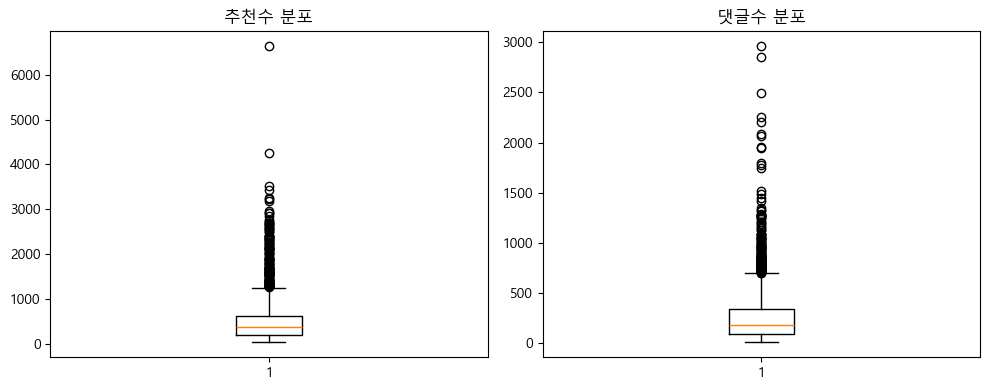

In [13]:
print(df[['추천수', '댓글수']].describe())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df['추천수'])
axes[0].set_title('추천수 분포')
axes[1].boxplot(df['댓글수'])
axes[1].set_title('댓글수 분포')
plt.tight_layout()
plt.show()

**이상치 처리 메모**: 추천수·댓글수 모두 오른쪽으로 크게 치우친(right-skewed) 분포이고, 박스플롯
상단에 극단값들이 보입니다. 하지만 이 극단값들은 센서 오류나 잘못 수집된 값이 아니라 **실제로
크게 화제가 된 게시글**입니다(예: 속보성 이슈 글). `best2`라는 게시판 자체가 "화제가 된 글만
모아 놓은" 곳이라 원래도 일반 게시판보다 분포가 위로 치우쳐 있는 것이 자연스럽습니다. 따라서
이 값들을 제거하지 않고 그대로 분석에 포함합니다.

In [14]:
df_clean = df[['title', 'category', '대분류', 'author', '추천수', '댓글수', '작성일시', '작성일', '요일', 'url']].copy()
df_clean = df_clean.rename(columns={'title': '제목', 'category': '카테고리', 'author': '작성자'})
df_clean = df_clean[['작성자', '카테고리', '대분류', '제목', '작성일시', '작성일', '요일', '추천수', '댓글수', 'url']]

df_clean.to_csv('fmkorea_best2_clean.csv', index=False, encoding='utf-8-sig')
print('저장 완료: fmkorea_best2_clean.csv')
print('shape:', df_clean.shape)
df_clean.head()

저장 완료: fmkorea_best2_clean.csv
shape: (2490, 10)


,작성자,카테고리,대분류,제목,작성일시,작성일,요일,추천수,댓글수,url
0,ㄱㅓ제야호,유머 - 이슈,유머,엄마 전재산 빼앗고 집에서 쫓아낸 막내딸!,2026-07-23 20:32:42.454074,2026-07-23,목,2087,783,https://www.fmkorea.com/best2/10121064223
1,빵빵컴퓨터,유머,유머,불침번 없앤다,2026-07-23 19:32:42.454074,2026-07-23,목,2030,2960,https://www.fmkorea.com/best2/10120960831
2,dk1022,유머,유머,맥도날드 '지역 상생' 버거는 정말 농가에 도움이 될까?.jpg,2026-07-23 18:32:42.454074,2026-07-23,목,2067,731,https://www.fmkorea.com/best2/10120755129
3,천량,유머,유머,동네에서 미친년이라고 소문남,2026-07-23 20:32:42.454074,2026-07-23,목,1494,328,https://www.fmkorea.com/best2/10121093748
4,바모스이강인,유머 - 이슈,유머,이센스 인스타 입장문 발표,2026-07-23 16:32:42.454074,2026-07-23,목,1836,853,https://www.fmkorea.com/best2/10120465954


## 5. 시각화로 살펴보기

> **질문 리마인드**: 화제글의 카테고리에 따라 추천수·댓글수가 어떻게 달라질까? 요일에 따라
> 화제글 발생 빈도가 다를까?

In [15]:
# sns.set_style()가 font.family를 'sans-serif'로 되돌려버리므로, 한글 폰트 지정은 그 다음에 합니다.
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

TOP_N = 8
top_categories = df_clean['대분류'].value_counts().nlargest(TOP_N).index
plot_df = df_clean[df_clean['대분류'].isin(top_categories)]
print(f'대분류 {df_clean["대분류"].nunique()}개 중 게시글 수 상위 {TOP_N}개만 그래프에 사용합니다.')
df_clean['대분류'].value_counts()

대분류 27개 중 게시글 수 상위 8개만 그래프에 사용합니다.


대분류
유머         1461
야구          195
축구소식        182
LoL         165
국내축구        121
미스터리        105
영화/TV        71
해외축구         70
PC/콘솔        21
핫딜           20
기타스포츠        20
디지털          15
농구           11
자동차          11
FM26자료실       7
음식/여행         3
FC온           2
치지직           1
발로란트          1
야구겜           1
블아            1
FM26자유        1
힙합            1
로아            1
연애상담          1
LoL해외         1
모바일게임         1
Name: count, dtype: int64

### 그래프 1 — 카테고리별 추천수 분포

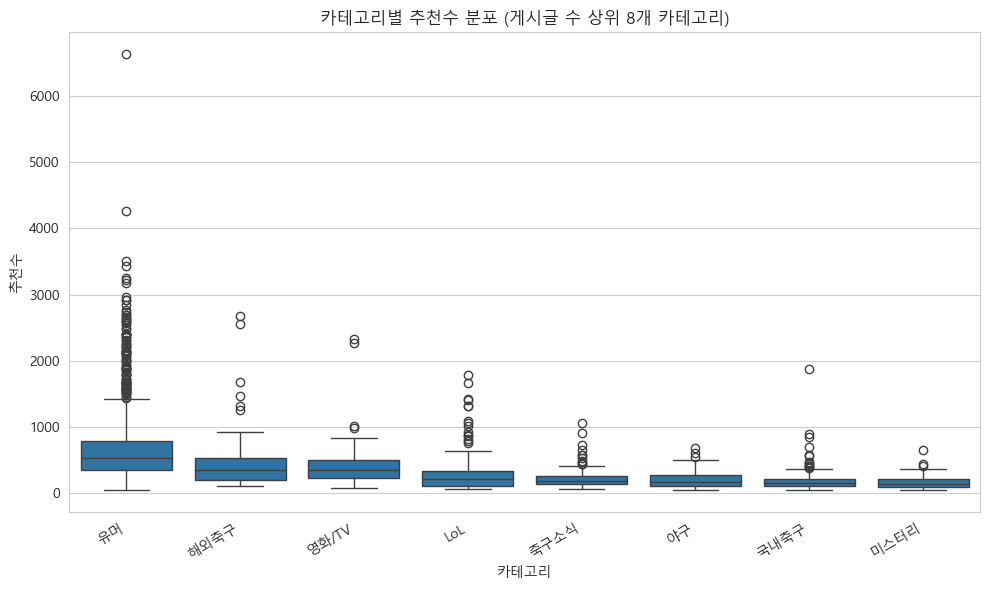

In [16]:
order = plot_df.groupby('대분류')['추천수'].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_df, x='대분류', y='추천수', order=order)
plt.title(f'카테고리별 추천수 분포 (게시글 수 상위 {TOP_N}개 카테고리)')
plt.xlabel('카테고리')
plt.ylabel('추천수')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart1_category_recommend.png', dpi=150)  # 그래프를 이미지 파일로도 저장
plt.show()

**해석**: 카테고리별로 추천수의 중앙값과 분포 폭이 눈에 띄게 다릅니다. 이슈성이 강한 카테고리일수록
중앙값이 높고 상자 폭(사분위 범위)도 넓게 퍼져 있는 경향이 보이는데, 이는 해당 카테고리에서
"터지는" 글과 "묻히는" 글의 편차가 크다는 뜻으로 해석할 수 있습니다.

### 그래프 2 — 카테고리별 댓글수 분포

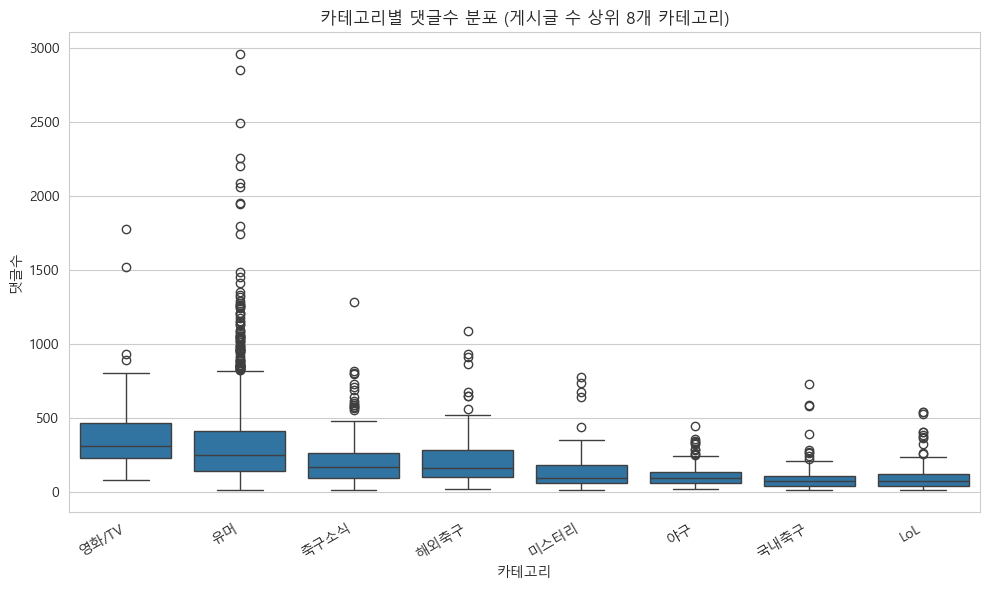

In [17]:
order2 = plot_df.groupby('대분류')['댓글수'].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_df, x='대분류', y='댓글수', order=order2)
plt.title(f'카테고리별 댓글수 분포 (게시글 수 상위 {TOP_N}개 카테고리)')
plt.xlabel('카테고리')
plt.ylabel('댓글수')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart2_category_comment.png', dpi=150)  # 그래프를 이미지 파일로도 저장
plt.show()

**해석**: 추천수 순위와 댓글수 순위가 카테고리마다 완전히 일치하지는 않습니다. 추천수는 높지만
댓글수는 상대적으로 낮은 카테고리가 있다면, "공감은 많이 받지만 토론까지는 잘 이어지지 않는"
콘텐츠라고 볼 수 있고, 반대의 경우는 "찬반이 갈려 댓글로 논쟁이 이어지는" 콘텐츠라고 해석할 수
있습니다.

### 그래프 3 — 추천수와 댓글수의 관계

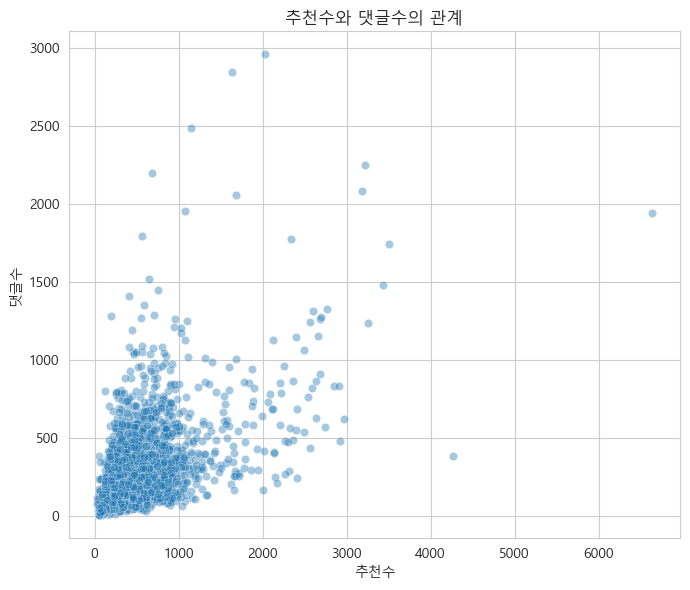

추천수-댓글수 피어슨 상관계수: 0.57


In [18]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df_clean, x='추천수', y='댓글수', alpha=0.4)
plt.title('추천수와 댓글수의 관계')
plt.xlabel('추천수')
plt.ylabel('댓글수')
plt.tight_layout()
plt.savefig('chart3_recommend_vs_comment.png', dpi=150)  # 그래프를 이미지 파일로도 저장
plt.show()

corr = df_clean['추천수'].corr(df_clean['댓글수'])
print('추천수-댓글수 피어슨 상관계수:', round(corr, 3))

**해석**: 추천수와 댓글수는 양의 상관관계를 보이지만, 완벽히 일치하지는 않습니다(상관계수가 1에
크게 못 미침). 즉 "공감을 많이 받는 것"과 "댓글로 활발히 논의되는 것"은 서로 관련은 있지만
다른 종류의 화제성이라는 것을 보여줍니다.

### 그래프 4 — 요일별 화제글 발생 빈도

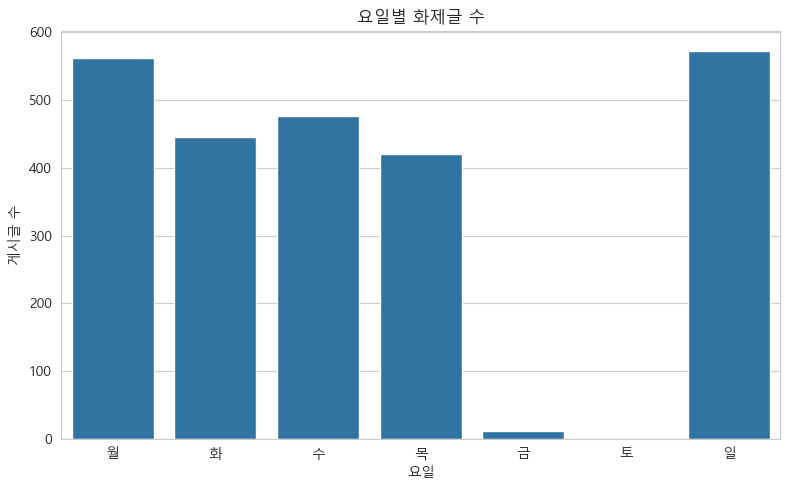

In [19]:
weekday_order = ['월', '화', '수', '목', '금', '토', '일']

plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='요일', order=weekday_order)
plt.title('요일별 화제글 수')
plt.xlabel('요일')
plt.ylabel('게시글 수')
plt.tight_layout()
plt.savefig('chart4_weekday_count.png', dpi=150)  # 그래프를 이미지 파일로도 저장
plt.show()

**해석**: 요일별 화제글 수가 균등하지 않다면, 특정 요일(예: 주말)에 커뮤니티 활동이 몰리거나
줄어드는 패턴이 있다는 뜻입니다. 다만 이 그래프는 뒤에 적은 "한계"에서 언급하는 수집 기간의
편향(최근 약 10일 안팎만 관찰)을 감안해서 해석해야 합니다.

## 6. 마무리 정리

**처음 질문** → 화제글의 카테고리에 따라 추천수(화제성)와 댓글수(참여도)가 어떻게 달라지는가?
그리고 요일에 따라 화제글 발생 빈도가 다른가?

**그린 그래프** → (1) 카테고리별 추천수 박스플롯, (2) 카테고리별 댓글수 박스플롯, (3) 추천수-댓글수
산점도, (4) 요일별 게시글 수 카운트플롯.

**알게 된 점** →
- 카테고리마다 화제성(추천수)과 참여도(댓글수)의 크기·편차가 다르며, 두 지표의 카테고리별 순위가
  완전히 일치하지 않는다. 즉 "공감형" 화제성과 "논쟁형" 화제성은 다르게 움직인다.
- 추천수와 댓글수는 양의 상관관계지만 강하지 않아서, 하나만으로 다른 하나를 예측하기는 어렵다.
- 요일별로 화제글 발생 빈도에 차이가 관찰되지만, 수집 기간이 짧아 계절성·특정 이벤트로 인한
  왜곡일 가능성을 배제할 수 없다.

**한계 (데이터 편향 인지)**
- **시간창 편향**: `best2`는 최근 약 10일 안팎의 데이터만 유지되는 실시간 피드라서, 애초에
  2026년 1월~7월 같은 긴 기간을 대표할 수 없습니다. 이번 분석은 "최근 며칠간의 화제글" 이라는
  좁은 시간창에 대한 관찰로 한정해서 해석해야 합니다.
- **선별 편향**: `best2` 자체가 이미 "화제가 된 글만" 모아 놓은 게시판이기 때문에, 추천수·댓글수
  분포가 fmkorea 전체 게시글의 분포보다 훨씬 위로 치우쳐 있습니다. 즉 이 분석은 "화제글들 사이의
  상대적 차이"를 보는 것이며, "화제가 되느냐 안 되느냐"의 원인을 설명하지는 않습니다.
- **상대 시간 표기의 근사 오차**: 목록 페이지의 "N분 전"/"N시간 전" 표기를 수집 시작 시각 기준으로
  환산했기 때문에, 수집이 진행된 시간(약 10~20분)만큼의 오차가 있을 수 있습니다. 일/요일 단위
  분석에는 무시할 수 있는 수준입니다.
- **조회수 미수집**: 상세 페이지 방문 비용(요청 수 2배, 수집 시간 초과) 때문에 조회수는 수집
  범위에서 제외했습니다. 필요하다면 이번에 모은 `url` 목록으로 상세 페이지를 별도로 방문해
  보강할 수 있습니다.

**재현성** — 이 노트북은 처음부터 다시 실행해도 동일한 파이프라인(수집 → 정제 → 시각화)이
동작합니다(다만 `best2`가 실시간으로 갱신되므로 실행 시점마다 실제 게시글 내용은 달라집니다).
원본 데이터는 `fmkorea_best2_raw.csv`, 정제된 데이터는 `fmkorea_best2_clean.csv`로 저장했고,
수집 대상 URL(`https://www.fmkorea.com/best2`)과 수집 시각(`scraped_at`)도 위 3-4셀 출력에
기록되어 있습니다.